# Neural Recommender Optimization Experiments

This notebook compares:

1. Gradient-based vs. PSO/evolutionary training of the same neural recommender.
2. Grid/random search vs. DE-style population-based hyperparameter optimization.
3. Standard DNN/GNN recommenders vs. hybrid RHMM-inspired, PSL-DNN, GNN-BiLSTM, and RL-optimized GNN aggregation variants.

Datasets:

- `MovieLens 100K` for fast local iteration.
- `ogbl-collab` from the Stanford Open Graph Benchmark as a larger graph-learning proxy.

Metrics:

- Accuracy: `ROC-AUC`, `average precision`, `binary accuracy`
- Time: wall-clock seconds
- Compute resources: peak RAM and peak GPU memory

## How To Read This Notebook

The notebook is organized as a simple pipeline:

1. Import the reusable experiment functions from `experiment_suite.py`.
2. Load the small and large datasets into a common edge-prediction format.
3. Run three suites of experiments:
   optimizer comparison, hyperparameter search comparison, and model-family comparison.
4. Aggregate the raw rows into a cleaner summary table.
5. Visualize the main trade-offs and then interpret the limitations.

Most of the heavy logic lives in the Python module so the notebook stays focused on orchestration and analysis.

In [1]:
# Optional installs for a fresh environment.
# %pip install numpy pandas matplotlib seaborn scikit-learn torch ogb psutil

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

# The experiment module holds the reusable loaders, models, and training loops.
from experiment_suite import (
    HAS_OGB,
    OGB_IMPORT_ERROR,
    RESULTS_DIR,
    describe_bundle,
    load_dataset_bundles,
    run_hpo_suite,
    run_model_family_suite,
    run_optimizer_suite,
)

sns.set_theme(style="whitegrid", context="talk")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# QUICK_MODE trims dataset sizes and training budgets so the notebook can
# be iterated on locally before committing to a longer run.
QUICK_MODE = True

print(f"Device: {DEVICE}")
print(f"OGB available: {HAS_OGB}")
if not HAS_OGB:
    print(f"OGB import error: {OGB_IMPORT_ERROR}")

Device: cpu
OGB available: True


In [3]:
# Each dataset is converted into the same GraphBundle structure so the
# experiment code can stay dataset-agnostic.
dataset_bundles = load_dataset_bundles(quick_mode=QUICK_MODE)
dataset_summary = pd.DataFrame([describe_bundle(bundle) for bundle in dataset_bundles.values()])
dataset_summary

c:\Users\kenny\anaconda3\envs\nn-rec-opt\Lib\site-packages\torch\serialization.py:1865: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  result = unpickler.load()


,dataset,task_type,num_nodes,train_edges,val_edges,test_edges,quick_mode,implicit_feedback,ogb_proxy_task
0,movielens_100k,bipartite,2601,32000,4000,4000,True,True,NaN
1,ogbl_collab,homogeneous,235868,120000,20000,20000,True,NaN,link_prediction


## Running The Experiment Suites

The next cell is the main execution cell.

- `run_optimizer_suite(...)` compares gradient-based training with population-based training.
- `run_hpo_suite(...)` compares grid/random search with DE-style search.
- `run_model_family_suite(...)` compares the baseline DNN/GNN models to the hybrid variants.

Each helper returns flat result rows so they can be concatenated into a single dataframe and saved to disk.

In [4]:
# Collect every experiment row in one list, then convert it into a single
# dataframe for later summarization and plotting.
all_rows = []
for name, bundle in dataset_bundles.items():
    print(f"Running optimizer suite for {name}")
    all_rows.extend(run_optimizer_suite(bundle, DEVICE))

    print(f"Running hyperparameter suite for {name}")
    all_rows.extend(run_hpo_suite(bundle, DEVICE))

    print(f"Running model-family suite for {name}")
    all_rows.extend(run_model_family_suite(bundle, DEVICE))

results_df = pd.DataFrame(all_rows)
results_df.to_csv(RESULTS_DIR / "experiment_results.csv", index=False)
results_df.head()

Running optimizer suite for movielens_100k
Running hyperparameter suite for movielens_100k
Running model-family suite for movielens_100k
Running optimizer suite for ogbl_collab
Running hyperparameter suite for ogbl_collab
Running model-family suite for ogbl_collab


,suite,dataset,model,method,val_auc,val_ap,val_accuracy,test_auc,test_ap,test_accuracy,loss_tail,wall_time_sec,peak_ram_mb,peak_gpu_mb,notes
0,optimizer_training,movielens_100k,dnn,adam,0.498030,0.493322,0.485000,0.481215,0.480899,0.486375,0.258068,2.370934,676.070312,0.0,
1,optimizer_training,movielens_100k,dnn,sgd,0.478726,0.492467,0.491375,0.499856,0.487972,0.492500,0.693173,1.791370,676.093750,0.0,
2,optimizer_training,movielens_100k,dnn,pso,0.560357,0.548971,0.532875,0.519953,0.530741,0.510250,NaN,1.131762,692.574219,0.0,Population-based training on the same neural r...
3,optimizer_training,movielens_100k,dnn,evolutionary,0.457921,0.474333,0.500000,0.505248,0.506076,0.500000,NaN,1.103701,687.917969,0.0,Population-based training on the same neural r...
4,hyperparameter_search,movielens_100k,dnn,grid_search,0.642906,0.585245,0.538500,0.637643,0.587595,0.534750,0.639577,0.549013,673.570312,0.0,"embedding_dim=16, hidden_dim=32, dropout=0.0, ..."


## Summarizing Results

The raw dataframe contains one row per training or search run. The next cell groups those rows into a cleaner comparison table using the best achieved test metrics and the observed resource usage.

In [5]:
# Group by suite / dataset / model / method so the notebook shows the
# strongest result reached by each approach.
summary_df = (
    results_df.groupby(["suite", "dataset", "model", "method"], dropna=False)
    .agg(
        test_auc=("test_auc", "max"),
        test_ap=("test_ap", "max"),
        test_accuracy=("test_accuracy", "max"),
        wall_time_sec=("wall_time_sec", "mean"),
        peak_ram_mb=("peak_ram_mb", "max"),
        peak_gpu_mb=("peak_gpu_mb", "max"),
    )
    .reset_index()
    .sort_values(["suite", "dataset", "test_auc"], ascending=[True, True, False])
)
summary_df

,suite,dataset,model,method,test_auc,test_ap,test_accuracy,wall_time_sec,peak_ram_mb,peak_gpu_mb
1,hyperparameter_search,movielens_100k,dnn,grid_search,0.710718,0.661613,0.648500,0.681035,677.222656,0.0
0,hyperparameter_search,movielens_100k,dnn,de_opt,0.681716,0.621953,0.600625,0.851990,684.562500,0.0
2,hyperparameter_search,movielens_100k,dnn,random_search,0.628667,0.575315,0.526000,0.804108,683.714844,0.0
4,hyperparameter_search,ogbl_collab,gnn,grid_search,0.781291,0.783567,0.691500,26.739358,706.726562,0.0
3,hyperparameter_search,ogbl_collab,gnn,de_opt,0.748634,0.804110,0.723775,46.421868,1150.925781,0.0
5,hyperparameter_search,ogbl_collab,gnn,random_search,0.745262,0.795758,0.736200,36.268381,1145.343750,0.0
6,model_family,movielens_100k,dnn,adam,0.524406,0.504659,0.481000,1.792041,681.855469,0.0
9,model_family,movielens_100k,psl_dnn,adam,0.471579,0.477348,0.482875,4.623184,724.449219,0.0
10,model_family,movielens_100k,rhmm,adam,0.463149,0.470702,0.477125,13.509873,724.195312,0.0
8,model_family,movielens_100k,gnn_bilstm,adam,0.458158,0.470647,0.481375,20.366706,746.328125,0.0


## Visual Comparison

These plots show the main accuracy trade-offs:

- left: optimizer comparison
- center: hyperparameter search comparison
- right: model family comparison

If you want to emphasize cost instead of accuracy, replace `test_auc` with `wall_time_sec`, `peak_ram_mb`, or `peak_gpu_mb`.

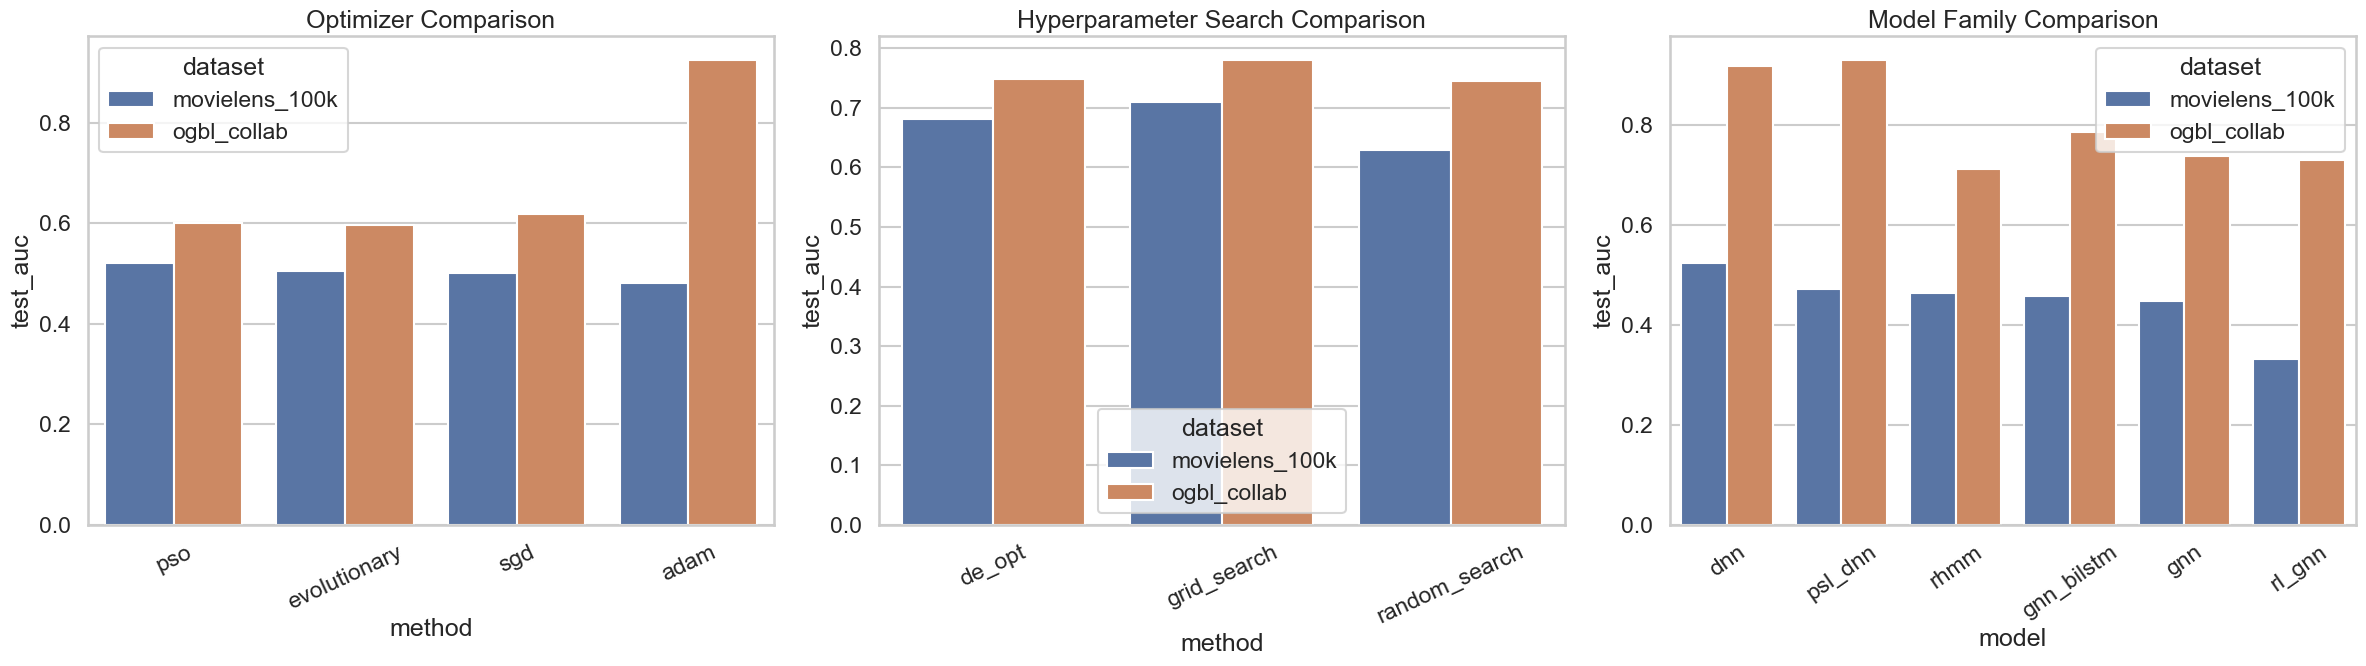

In [6]:
# Build one chart per experiment family so the comparisons stay readable.
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

optimizer_plot = summary_df[summary_df["suite"] == "optimizer_training"]
sns.barplot(data=optimizer_plot, x="method", y="test_auc", hue="dataset", ax=axes[0])
axes[0].set_title("Optimizer Comparison")
axes[0].tick_params(axis="x", rotation=25)

hpo_plot = summary_df[summary_df["suite"] == "hyperparameter_search"]
if not hpo_plot.empty:
    hpo_best = hpo_plot.groupby(["dataset", "method"], as_index=False).agg(test_auc=("test_auc", "max"))
    sns.barplot(data=hpo_best, x="method", y="test_auc", hue="dataset", ax=axes[1])
axes[1].set_title("Hyperparameter Search Comparison")
axes[1].tick_params(axis="x", rotation=25)

family_plot = summary_df[summary_df["suite"] == "model_family"]
sns.barplot(data=family_plot, x="model", y="test_auc", hue="dataset", ax=axes[2])
axes[2].set_title("Model Family Comparison")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

## Limitations

1. MovieLens is transformed into implicit feedback by binarizing ratings at `>= 4`, so this study emphasizes ranking/link prediction rather than calibrated rating regression.
2. `ogbl-collab` is a realistic large-scale graph benchmark, but it is still a proxy for recommender systems rather than a production user-item interaction log.
3. The hybrid models are practical approximations:
   `RHMM` is implemented as a regime-aware recurrent surrogate, `PSL-DNN` uses soft graph heuristics instead of a full PSL engine, and the RL aggregator uses a lightweight bandit controller.
4. Population-based optimization is computationally expensive for neural recommenders, so the default notebook budgets are intentionally conservative.
5. Runtime and memory results are machine-dependent; compare methods on the same hardware for fair conclusions.
6. For stronger scientific claims, repeat runs with multiple seeds and add confidence intervals, ranking metrics such as `NDCG@K`, and exact paper implementations where needed.